This python code is dedicated for symbolic polynomial manipulation. Our goal is to define polynomials as new python objects out of lists, i.e :
$$[a_O, a_1, \dots, a_n] \rightarrow P=a_0 + a_1 X+ \dots a_n X^n  $$ 
and to perform the usual operations on them, as objects. We also will be using Latex for visulazation purposes, And a final mini-software dedicated for polynomial manipulation and operations, equipped with a graphical envirement.


In [103]:
# This program is designed to manipulate polynomials symbolically. This includes summation, multiplication, derivation, and some other useful methods.

# LaTex modules in order to print down polynomials in their LaTex form 
from IPython.display import display, Latex

# modules needed for visual manipulation
import numpy as np
import matplotlib.pyplot as plt

# first of all, we are going to define polynomials as python objects. 
class poly:
    def __init__(self, coefs):
        self.coefs = coefs

    def deg(self):  # to compute the degree, we put into consideration that sometimes the user inputs zero coefficients. 
        if not any(self.coefs):  # i.e., all coefs being zero, then the zero polynomial, we turn back -infty. 
            return "-infty"
        else:
            inv = list(self.coefs)
            inv.reverse()
            for i, coef in enumerate(inv):
                if coef != 0:
                    return len(self.coefs) - i - 1

    def disp(self):  # displaying the form of the polynomial in latex
        latex_code = "$"
        for i in range(len(self.coefs)):
            if self.coefs[i] != 0: 
                if i == 0:
                    latex_code += f"{self.coefs[i]} + "
                elif i == 1:
                    latex_code += f"{self.coefs[i]} X + "
                else:
                    latex_code += f"{self.coefs[i]} X^{{{i}}} + "
        display(Latex(latex_code[:-2] + "$"))

    def evalu(self, x):  # a method to evaluate the polynomial at a given real value 
        return self.coefs[0] + sum([self.coefs[i] * (x ** i) for i in range(1, len(self.coefs))])

    def is_root(self, x):  # a method that checks if a given value is a root of the polynomial  
        return self.evalu(x) == 0

    def deriv(self):  # a method that computes the derivative of a polynomial 
        for i in range(1, len(self.coefs)):
            self.coefs[i - 1] = self.coefs[i] * i
        self.coefs[-1] = 0

    def poly_plot(self, x_min=-10, x_max=10, num_points=100, points=None):  # plotting the polynomial visually
        x = np.linspace(x_min, x_max, num_points)
        y = [self.evalu(val) for val in x]
        
        # Plotting the polynomial curve in blue
        plt.plot(x, y, label="Polynomial", color="blue")
        
        # Plotting specified points in red with values shown
        if points is not None:
            py = [self.evalu(p_x) for p_x in points]  # Calculate y-values for each x in points
            plt.scatter(points, py, color="red", s=50, label="Specified Points", zorder=5)  # Red points
            for p_x, p_y in zip(points, py):
                plt.annotate(f"{p_y}", (p_x, p_y), textcoords="offset points", xytext=(0,5), ha="center", fontsize=8, color="red", fontweight="bold")
        
        plt.xlabel("x")
        plt.ylabel("P(x)")
        plt.title("Polynomial Plot with Specified Points")
        plt.axhline(0, color='black', linewidth=0.5)
        plt.axvline(0, color='black', linewidth=0.5)
        plt.grid(True)
        plt.legend()
        plt.show()
        P.disp()


Some examples

In [104]:
# we define a polynomial P, we display its form, and we compute its degree.
P=poly([1,2,0,5,0])
P.disp()
P.deg()

<IPython.core.display.Latex object>

3

In [105]:
# the value of the polynomial at 0 (it has to be equal to the first coefficient)
print(P.evalu(1))
print(P.is_root(1))

8
False


In [106]:
# example of polynomial derivation 
P.deriv()
P.disp()
P.deg()

<IPython.core.display.Latex object>

2

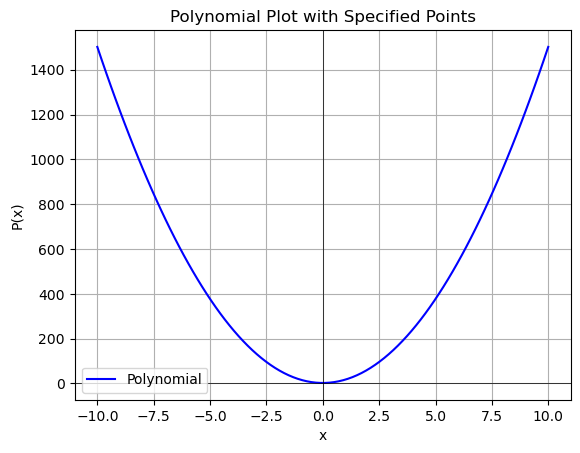

<IPython.core.display.Latex object>

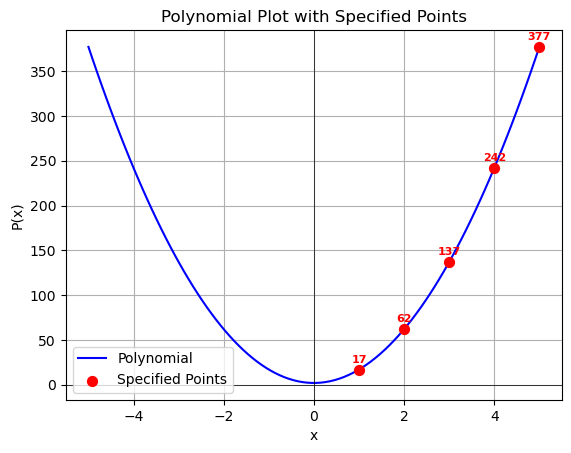

<IPython.core.display.Latex object>

In [107]:
# example of a polynomial plot 
P.poly_plot()
P.poly_plot(-5,5,100,[1,2,3,4,5])

In [108]:
# now that we went through methods associated to a single polynomials, we go through operations on plynomials

def poly_sum(P: poly, Q: poly):
    if P.deg() > Q.deg():
        Q.coefs=Q.coefs+[0 for i in range(P.deg()-Q.deg())]
    else:
        P.coefs=P.coefs+[ 0 for i in range(Q.deg()-P.deg())]
    return poly([a+b for a,b in zip(Q.coefs, P.coefs)]) 

# example (notice they are of diffirence degrees)
P=poly([0,1,3,4])
Q=poly([2,3,5])
poly_sum(P,Q).disp()

<IPython.core.display.Latex object>

In [109]:
# finally we define the "required" plynomial multiplication function 
def poly_prod(P: poly, Q: poly):
    prod_coefs = []
    for i in range(P.deg() + Q.deg() + 1):
        prod_coefs.append(sum(P.coefs[k] * Q.coefs[i - k] for k in range(max(0, i - Q.deg()), min(i, P.deg()) + 1)))
    return poly(prod_coefs) 

# example
P = poly([1, 1, 2])
Q = poly([0, 1, 1]) 
poly_prod(P, Q).disp() 


<IPython.core.display.Latex object>

In [110]:
# we can showcase, that, indeed roots of the given polynomials are roots for the the product.
# we put : 
P=poly([-1,0,1])
P.disp()
Q=poly([2,1])
Q.disp()
R= poly_prod(P,Q) 
R.disp()

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [111]:
#we show the roots of P and Q: ( we can see that all root verifications would give a zero )
print(P.is_root(1))
print(P.is_root(-1))
print(Q.is_root(-2))
print(R.is_root(1))
print(R.is_root(-1))
print(R.is_root(-2))

True
True
True
True
True
True


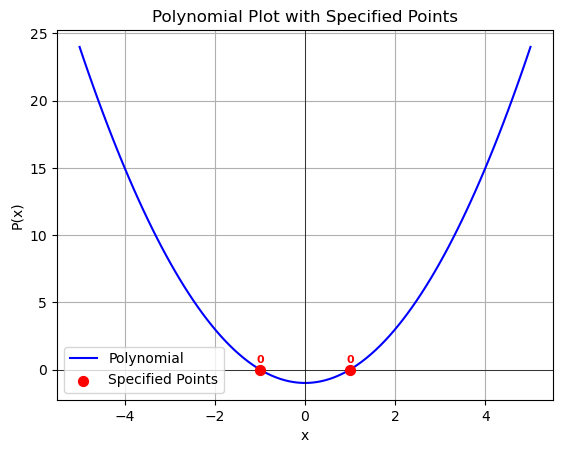

<IPython.core.display.Latex object>

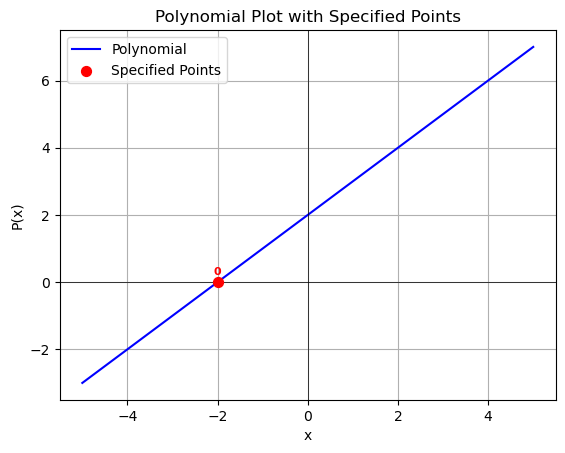

<IPython.core.display.Latex object>

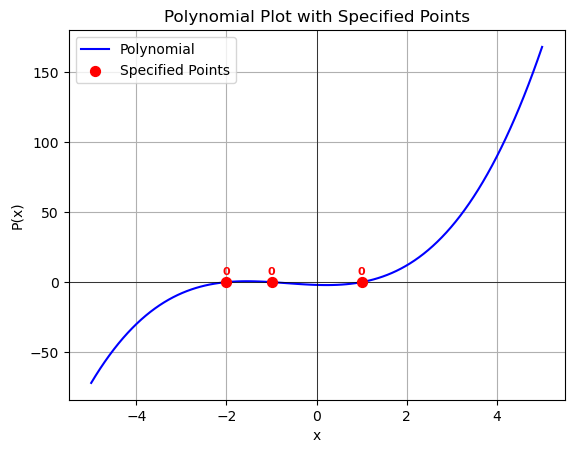

<IPython.core.display.Latex object>

In [112]:
#we will furthermore graphically verify the result :
P.poly_plot(-5,5,100,[1,-1])
Q.poly_plot(-5, 5, 100, [-2])
R.poly_plot(-5,5, 100, [1,-1,-2])

#This is,at least a simple showcase of an elementary result using our polynomial class, and the mulipilication fucntion. 